In [15]:
from __future__ import print_function, division   # Ensures Python3 printing & division standard
import pandas as pd 
from pandas import Series, DataFrame 
from matplotlib import pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.metrics import confusion_matrix
import lightgbm as lgb
from lightgbm import early_stopping
import time
import shap
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from tqdm.notebook import tqdm
from matplotlib import pyplot as plt
import warnings
warnings.filterwarnings("ignore")

SavePlots = False

data = pd.DataFrame(np.genfromtxt('data_mice_encoded_aggr.csv', delimiter=',', names=True))

target = 'CLAIM_COUNT'

features = [
    col for col in data.columns
    if col not in ['CLAIM_COUNT', 'CLAIM_SIZE', 'CLAIM_SIZE_INDEX', 
                   'f0', 'EXPOSURE', 'POLICY', 'OUTER_WALLS', 'HEATING_TYPE', 
                   'WATER_SUPPLY_TYPE', 'ROOF_TYPE', 'CLAIM_RATE']
]

data = data[data["EXPOSURE"] > 0]

X = data[features]
y = data[target]

feature_names = np.array(X.columns)

exposure = data["EXPOSURE"]

In [16]:
print(sum(data['CLAIM_SIZE_INDEX'])/6)

45824592.54409525


In [17]:
#Feature set for claim size:
top_unique = ['CONSTRUCTION_YEAR', 
              'HOUDEN10KM', 
              'DEDUCTIBLE', 
              'RESIDENTIAL_AREA', 
              'ROOF_TYPE_CAT_Thatched_Roof', 
              'BUILDINGS', 
              'WATER_SUPPLY_TYPE_CAT_Private_Water_Supply', 
              'BASEMENT_AREA', 
              'OUTER_WALLS_CAT_Brick_Walls', 
              'HEATING_TYPE_CAT_Central_Heating_Own_System',
              'YEAR',
              'WETROOMS']



# Feature set for claim count
top20_stability = ['EXPOSURE', 
                   'DEDUCTIBLE', 
                   'CONSTRUCTION_YEAR', 
                   'HEATING_TYPE_CAT_District_Heating', 
                   'RESIDENTIAL_AREA', 
                   'HOUDEN10KM', 
                   'WATER_SUPPLY_TYPE_CAT_Water_Extraction_Plant', 
                   'HEATING_TYPE_CAT_Heat_Pump', 
                   'BUILDINGS', 
                   'BASEMENT_AREA', 
                   'HEATING_TYPE_CAT_Central_Heating_Two_Units', 
                   'HEATING_TYPE_CAT_Stove_Fireplace', 
                   'CONSERVATORY_AREA', 
                   'WATER_SUPPLY_TYPE_CAT_Non_Public_Water_Supply', 
                   'ROOF_TYPE_CAT_Tar_Paper', 
                   'WETROOMS', 
                   'ROOF_TYPE_CAT_Concrete_Tiles', 
                   'ROOF_TYPE_CAT_Fiber_Cement_Asbestos',
                   'WATER_SUPPLY_TYPE_CAT_Mixed_Water_Supply', 
                   'WATER_SUPPLY_TYPE_CAT_Well_Water']



In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from catboost import CatBoostRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from tqdm.auto import tqdm


TARGET_EXPOSURE = 90000
N_SIMULATIONS = 1000

data = pd.DataFrame(
    np.genfromtxt(
        "data_mice_encoded.csv",
        delimiter=",",
        names=True
    )
)

count_features = top20_stability
severity_features = top_unique

X_count = data[count_features].astype(np.float32)
y_count = data["CLAIM_COUNT"].values

severity_data = data[data["CLAIM_COUNT"] > 0].copy()
X_sev = severity_data[severity_features].astype(np.float32)
y_sev = severity_data["CLAIM_SIZE_INDEX"].values

count_model = CatBoostRegressor(
    iterations=3000,
    depth=6,
    l2_leaf_reg=14,
    learning_rate=0.032269,
    loss_function="RMSE",
    verbose=0,
    random_seed=42
)

count_model.fit(X_count, y_count)

severity_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPRegressor(
        hidden_layer_sizes=(64, 64),
        alpha=0.0008898416750158575,
        learning_rate_init=0.0006263298840589133,
        max_iter=1000,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20,
        random_state=42
    ))
])

severity_model.fit(X_sev, y_sev)


obs_count = np.sum(y_count)
pred_count = np.sum(count_model.predict(X_count))

print("\n===== MODEL CALIBRATION =====")
print(f"Observed Claim Count : {obs_count:,.0f}")
print(f"Predicted Claim Count: {pred_count:,.0f}")
print(f"Count Ratio          : {pred_count / obs_count:.4f}")


portfolio_yearly_losses = []

claimant_counts = []
total_claim_counts = []

pbar = tqdm(range(N_SIMULATIONS), desc="Simulating portfolios")

for sim in pbar:

    sampled_rows = []
    exposure_sum = 0.0

    while exposure_sum < TARGET_EXPOSURE:

        row = data.sample(n=1, replace=True)
        sampled_rows.append(row)
        exposure_sum += row["EXPOSURE"].iloc[0]

    portfolio = pd.concat(sampled_rows, ignore_index=True)

    claim_count_pred = count_model.predict(portfolio[count_features])
    claim_count_pred = np.maximum(claim_count_pred, 0)

    portfolio = portfolio.copy()
    portfolio["PRED_CLAIM_COUNT"] = claim_count_pred

    claimants = portfolio[portfolio["PRED_CLAIM_COUNT"] > 0].copy()
    portfolio["IS_CLAIMANT"] = (portfolio["PRED_CLAIM_COUNT"] > 0).astype(int)

    if len(claimants) > 0:

        sev_pred = severity_model.predict(claimants[severity_features])
        sev_pred = np.maximum(sev_pred, 0)

        # frequency-weighted severity (deterministic)
        claim_sizes = sev_pred * claimants["PRED_CLAIM_COUNT"].values

        total_severity = np.sum(claim_sizes)

    else:
        total_severity = 0.0

    portfolio_yearly_losses.append(total_severity)

    claimant_counts.append(len(claimants))
    total_claim_counts.append(np.sum(claim_count_pred))


    pbar.set_postfix({
            "loss": f"{total_severity:,.0f}",
            "claims": float(np.sum(claim_count_pred))
        })


portfolio_yearly_losses = np.array(portfolio_yearly_losses)

print("\n===== YEARLY LOSS DISTRIBUTION =====")
print(f"Mean Loss : {portfolio_yearly_losses.mean():,.2f}")
print(f"Std Loss  : {portfolio_yearly_losses.std():,.2f}")
print(f"VaR95     : {np.percentile(portfolio_yearly_losses, 95):,.2f}")
print(f"VaR99     : {np.percentile(portfolio_yearly_losses, 99):,.2f}")
print(f"Min Loss  : {portfolio_yearly_losses.min():,.2f}")
print(f"Max Loss  : {portfolio_yearly_losses.max():,.2f}")

print("\n===== CLAIMANT STATS =====")
print(f"Avg claimants per portfolio: {np.mean(claimant_counts):,.2f}")
print(f"Avg total predicted claims : {np.mean(total_claim_counts):,.2f}")


===== MODEL CALIBRATION =====
Observed Claim Count : 4,987
Predicted Claim Count: 4,986
Count Ratio          : 0.9998


Simulating portfolios:   0%|          | 0/1000 [00:00<?, ?it/s]


===== YEARLY LOSS DISTRIBUTION =====
Mean Loss : 45,848,968.47
Std Loss  : 261,117.72
VaR95     : 46,269,672.16
VaR99     : 46,496,479.54
Min Loss  : 45,029,574.83
Max Loss  : 46,790,329.98

===== CLAIMANT STATS =====
Avg claimants per portfolio: 159,013.66
Avg total predicted claims : 834.44


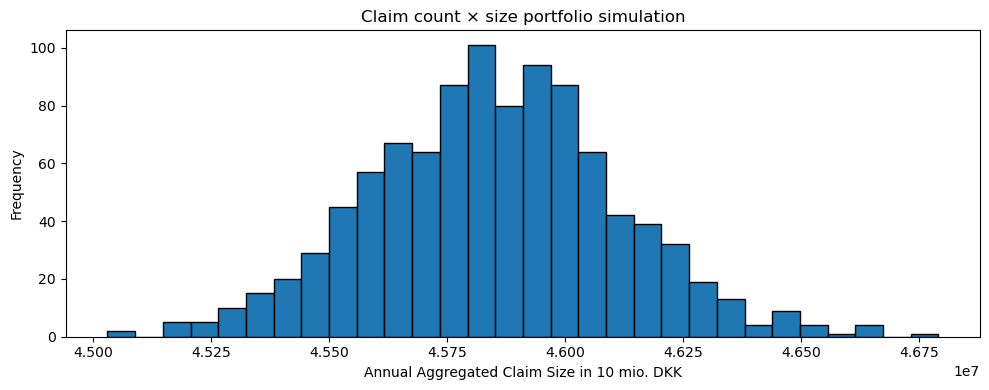

In [20]:
plt.figure(figsize=(10, 4))
plt.hist(
    portfolio_yearly_losses,
    bins=30,
    edgecolor="black",
    linewidth=1
)
plt.xlabel("Annual Aggregated Claim Size in 10 mio. DKK")
plt.ylabel("Frequency")
plt.title("Claim count × size portfolio simulation")
plt.tight_layout()
plt.show()